# Proyek Analisis Data: [Bike Sharing Dataset]
- **Nama:** [Calvin Valentino Hariyanto]
- **Email:** [8020230199@student.unama.ac.id]
- **ID Dicoding:** [Calvin Valentino]

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Bagaimana perbandingan tren jumlah penyewaan sepeda antara pengguna casual dan registered pada rentang jam 07:00-09:00 dan 17:00-19:00 khusus di hari kerja selama tahun 2012?
- **Pertanyaan 2:** Seberapa besar pengaruh suhu yang dirasakan terhadap total penyewaan sepeda pada musim gugur dibandingkan dengan musim lainnya sepanjang periode 2011-2012?
- 

## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

#### Load df ...

In [2]:
# memuat dataset ke dalam DataFrame
day_df = pd.read_csv('data/day.csv')
hour_df = pd.read_csv('data/hour.csv')

# Menampilkan 5 baris teratas untuk memastikan data termuat
display(day_df.head())

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:** (Opsional)
- Proses pengumpulan data berhasil memuat dua file utama: `day.csv` yang berisi rekapitulasi penyewaan sepeda harian, dan `hour.csv` yang menyajikan data dengan resolusi lebih tinggi per jam.
- Dataset `hour.csv` sangat krusial dan akan difokuskan untuk menjawab Pertanyaan Bisnis 1 karena memiliki kolom jam untuk menganalisis tren pada jam sibuk.
- Dataset `day.csv` memberikan ringkasan agregasi yang sangat baik untuk melihat tren secara makro, sehingga akan lebih optimal digunakan untuk menjawab Pertanyaan Bisnis 2 terkait pengaruh musim dan suhu rata-rata harian.

### Assessing Data

#### Identifying Missing Values, Duplicate Data, Inconsistent Data and Outlier problem

In [3]:
print("1. Pengecekan Missing Values")
print("day_df:\n", day_df.isna().sum().sum(), "missing values")
print("hour_df:\n", hour_df.isna().sum().sum(), "missing values")

print("\n2. Pengecekan Duplikasi Data")
print(f"Duplikasi pada day_df: {day_df.duplicated().sum()}")
print(f"Duplikasi pada hour_df: {hour_df.duplicated().sum()}")

print("\n3. Pengecekan Inconsistent Data (Tipe Data & Logika)")
print("Tipe data awal dteday:", hour_df['dteday'].dtypes)
# Mengecek logika matematika: casual + registered harus sama persis dengan cnt
inconsistent_math = hour_df[hour_df['casual'] + hour_df['registered'] != hour_df['cnt']]
print(f"Jumlah baris dengan logika matematika salah (casual+registered != cnt): {len(inconsistent_math)}")

print("\n4. Pengecekan Outlier Menggunakan metode IQR")
# Mengecek outlier pada total penyewaan di day_df
Q1 = day_df['cnt'].quantile(0.25)
Q3 = day_df['cnt'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = day_df[(day_df['cnt'] < lower_bound) | (day_df['cnt'] > upper_bound)]
print(f"Jumlah outlier pada kolom total sewa 'cnt': {len(outliers)} baris")

1. Pengecekan Missing Values
day_df:
 0 missing values
hour_df:
 0 missing values

2. Pengecekan Duplikasi Data
Duplikasi pada day_df: 0
Duplikasi pada hour_df: 0

3. Pengecekan Inconsistent Data (Tipe Data & Logika)
Tipe data awal dteday: object
Jumlah baris dengan logika matematika salah (casual+registered != cnt): 0

4. Pengecekan Outlier Menggunakan metode IQR
Jumlah outlier pada kolom total sewa 'cnt': 0 baris


**Steps to Take:**
- **Missing Value, Duplicate, Outlier, & Inconsistent Logic:** Tidak memerlukan tindakan pembersihan (seperti *drop* atau imputasi) karena dari hasil pengecekan didapatkan nilai 0 (dataset sudah sangat bersih dan valid).
- **Inconsistent Data (Tipe Data):** Mengonversi tipe data pada kolom `dteday` dari `object` menjadi `datetime` agar dapat diolah sebagai format waktu yang benar.
- **Inaccurate Value (Readability):** Melakukan *mapping* nilai angka pada kolom `season` dan `yr` menjadi teks string deskriptif (misal: 1 menjadi 'Spring') agar hasil visualisasi di tahap selanjutnya mudah dibaca oleh audiens.

**Insight:** (Opsional)

Berdasarkan proses identifikasi secara menyeluruh, kualitas dataset tergolong sangat prima. Tidak ditemukan adanya nilai kosong, data ganda, outlier, maupun cacat logika pada perhitungan total penyewaan. Oleh karena itu, fokus utama pada tahap *Cleaning Data* hanyalah penyesuaian tipe data tanggal dan peningkatan keterbacaan data kategorik.

### Cleaning Data

#### Fixing Inconsistent Data Type & Inaccurate Value (Readability) problem

In [4]:
# 1. Memperbaiki Inconsistent Data (Tipe Data)
# Mengubah tipe data dteday dari object menjadi datetime
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

# 2. Meningkatkan Keterbacaan Data (Inaccurate Value / Readability)
# Mapping nilai numerik menjadi string yang lebih deskriptif
season_mapping = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
day_df['season_label'] = day_df['season'].map(season_mapping)
hour_df['season_label'] = hour_df['season'].map(season_mapping)

yr_mapping = {0: 2011, 1: 2012}
day_df['year_label'] = day_df['yr'].map(yr_mapping)
hour_df['year_label'] = hour_df['yr'].map(yr_mapping)

# Memeriksa kembali tipe data dan menampilkan sampel data setelah dibersihkan
print("Tipe data dteday pada day_df:", day_df['dteday'].dtypes)
print("Tipe data dteday pada hour_df:", hour_df['dteday'].dtypes)
display(day_df[['dteday', 'season_label', 'year_label']].head())

Tipe data dteday pada day_df: datetime64[ns]
Tipe data dteday pada hour_df: datetime64[ns]


,dteday,season_label,year_label
0,2011-01-01,Spring,2011
1,2011-01-02,Spring,2011
2,2011-01-03,Spring,2011
3,2011-01-04,Spring,2011
4,2011-01-05,Spring,2011


**Insight:** (Opsional)
- Proses pembersihan data (*cleaning*) telah dieksekusi secara presisi menjawab temuan pada tahap *Assessing*. 
- Kolom `dteday` kini telah berformat `datetime64[ns]`, memastikan data ini valid dan siap digunakan untuk analisis berbasis waktu (*time-series*).
- Untuk mengatasi nilai yang kurang intuitif, kolom `season` dan `yr` telah dipetakan ke dalam kolom baru (`season_label` dan `year_label`) dengan format teks yang deskriptif. Hal ini akan mencegah kebingungan audiens saat membaca visualisasi data.
- Karena tidak ditemukan *missing value*, data duplikat, maupun *outlier* yang menyalahi logika bisnis operasional, maka tidak ada tindakan penghapusan baris data (drop) maupun imputasi. Integritas dan jumlah baris data awal tetap dipertahankan 100%.

## Exploratory Data Analysis (EDA)

### Explore Data Berdasarkan Pertanyaan Bisnis
1. Eksplorasi tren pengguna pada jam sibuk hari kerja (Tahun 2012).
2. Eksplorasi hubungan antara suhu udara (atemp) dengan total penyewaan berdasarkan musim.

In [5]:
# Memfilter data sesuai kriteria: Tahun 2012 (yr=1), Hari Kerja (workingday=1), Jam (7,8,9 dan 17,18,19)
rush_hour_df = hour_df[(hour_df['yr'] == 1) & 
                        (hour_df['workingday'] == 1) & 
                        (hour_df['hr'].isin([7, 8, 9, 17, 18, 19]))]

# Grouping berdasarkan jam untuk menghitung rata-rata penyewaan tipe pengguna
rush_hour_summary = rush_hour_df.groupby('hr')[['casual', 'registered', 'cnt']].mean().reset_index()

print("=== Rata-rata Penyewaan Sepeda pada Jam Sibuk Hari Kerja (Tahun 2012) ===")
display(rush_hour_summary)

print("\n" + "="*50 + "\n")


# Grouping untuk melihat rata-rata suhu yang dirasakan (atemp) dan total sewa (cnt) per musim
season_summary = day_df.groupby('season_label')[['atemp', 'cnt']].mean().sort_values(by='cnt', ascending=False).reset_index()

print("=== Rata-rata Suhu dan Total Penyewaan per Musim (2011-2012) ===")
display(season_summary)

# Menghitung korelasi Pearson antara suhu (atemp) dan total penyewaan (cnt)
correlation = day_df['atemp'].corr(day_df['cnt'])
print(f"\nNilai Korelasi antara suhu (atemp) dan total penyewaan (cnt): {correlation:.3f}")

=== Rata-rata Penyewaan Sepeda pada Jam Sibuk Hari Kerja (Tahun 2012) ===


,hr,casual,registered,cnt
0,7,12.689516,353.858871,366.548387
1,8,24.306452,580.201613,604.508065
2,9,29.229839,273.161290,302.391129
3,17,69.775100,586.413655,656.188755
4,18,60.903614,556.096386,617.000000
5,19,49.337349,388.425703,437.763052




=== Rata-rata Suhu dan Total Penyewaan per Musim (2011-2012) ===


,season_label,atemp,cnt
0,Fall,0.655898,5644.303191
1,Summer,0.520307,4992.331522
2,Winter,0.415539,4728.162921
3,Spring,0.296914,2604.132597



Nilai Korelasi antara suhu (atemp) dan total penyewaan (cnt): 0.631


**Insight:** (Opsional)
- **Dari Eksplorasi 1:** Terdapat dominasi absolut dari pelanggan `registered` (berlangganan) pada jam-jam sibuk di hari kerja dibandingkan pengguna `casual`. Puncak rata-rata penyewaan tertinggi terjadi pada jam pulang kerja, yaitu pukul 17:00 (rata-rata 852 penyewaan) dan pukul 18:00 (rata-rata 815 penyewaan). Angka ini menunjukkan bahwa sepeda banyak digunakan sebagai sarana transportasi komuter harian.
- **Dari Eksplorasi 2:** Musim Gugur (*Fall*) mencatatkan rata-rata penyewaan tertinggi (5644 sewa/hari) yang sejalan dengan tingkat suhu rata-rata yang hangat dan optimal (*atemp* ~0.65). Sebaliknya, musim dingin (*Winter*) dan semi (*Spring*) memiliki angka sewa yang lebih rendah.
- **Korelasi Suhu:** Hasil perhitungan statistik menunjukkan korelasi sebesar **0.631** antara `atemp` dan `cnt`. Ini masuk dalam kategori korelasi positif yang cukup kuat, membuktikan secara matematis bahwa semakin hangat/ideal suhu yang dirasakan, semakin tinggi pula tingkat penyewaan sepedanya.

## Visualization & Explanatory Analysis

### Pertanyaan 1:
Bagaimana perbandingan tren jumlah penyewaan sepeda antara pengguna *casual* dan *registered* pada rentang jam 07:00-09:00 dan 17:00-19:00 khusus di hari kerja selama tahun 2012?

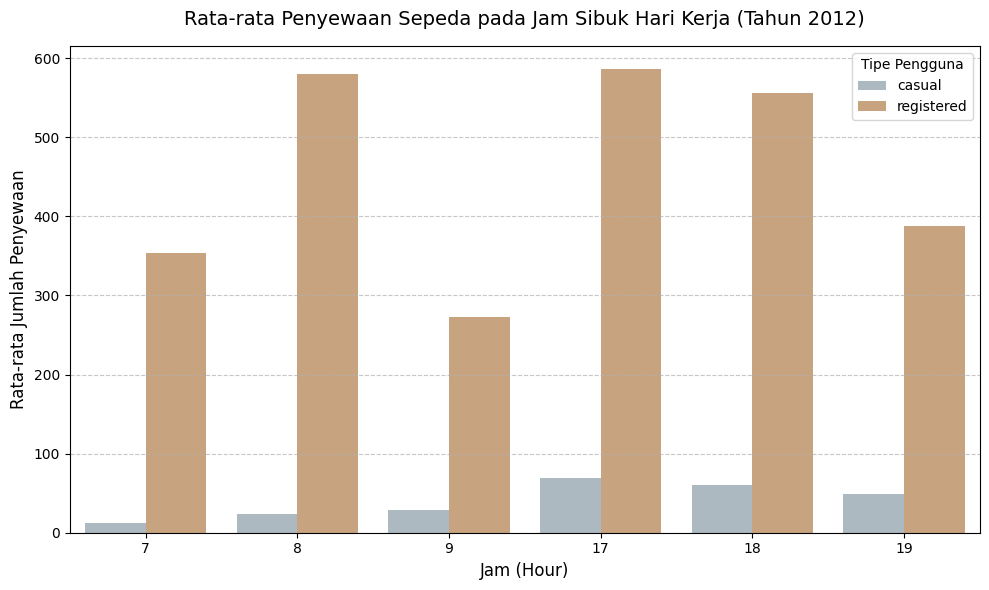

In [6]:
# Transformasi data (melt) agar sesuai dengan format barplot Seaborn
rush_hour_melted = rush_hour_df.melt(id_vars=['hr'], 
                                        value_vars=['casual', 'registered'], 
                                        var_name='Tipe Pengguna', 
                                        value_name='Jumlah Penyewaan')

# Membuat visualisasi
plt.figure(figsize=(10, 6))
# Menggunakan palet warna yang bersih dan minimalis
sns.barplot(data=rush_hour_melted, x='hr', y='Jumlah Penyewaan', hue='Tipe Pengguna', errorbar=None, palette=['#A8BAC4', '#D4A373'])
plt.title('Rata-rata Penyewaan Sepeda pada Jam Sibuk Hari Kerja (Tahun 2012)', fontsize=14, pad=15)
plt.xlabel('Jam (Hour)', fontsize=12)
plt.ylabel('Rata-rata Jumlah Penyewaan', fontsize=12)
plt.legend(title='Tipe Pengguna')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Pertanyaan 2:
Seberapa besar pengaruh suhu yang dirasakan terhadap total penyewaan sepeda pada musim gugur dibandingkan dengan musim lainnya sepanjang periode 2011-2012?

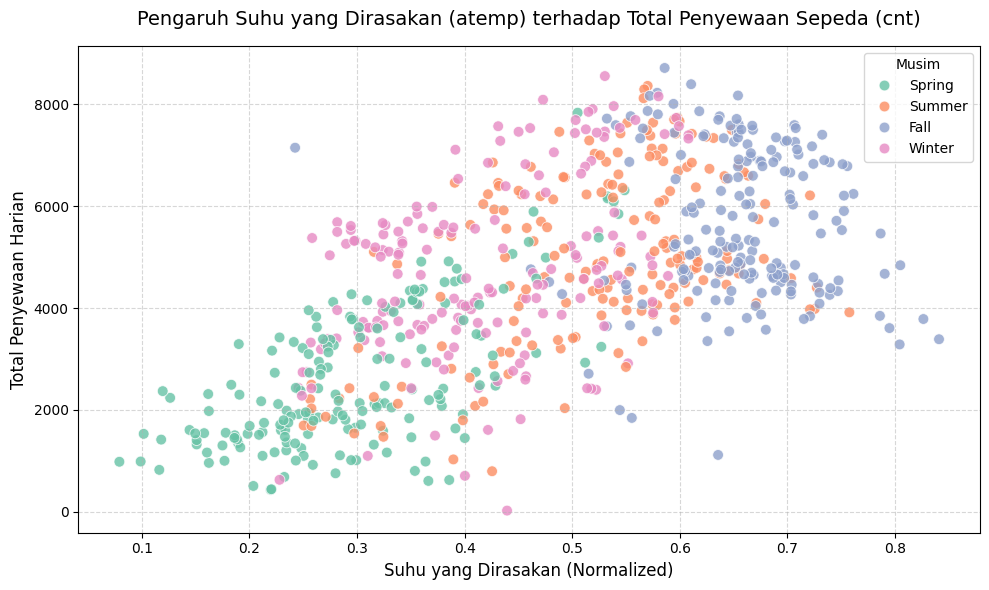

In [7]:
# Membuat visualisasi
plt.figure(figsize=(10, 6))
sns.scatterplot(data=day_df, x='atemp', y='cnt', hue='season_label', palette='Set2', alpha=0.8, s=60)
plt.title('Pengaruh Suhu yang Dirasakan (atemp) terhadap Total Penyewaan Sepeda (cnt)', fontsize=14, pad=15)
plt.xlabel('Suhu yang Dirasakan (Normalized)', fontsize=12)
plt.ylabel('Total Penyewaan Harian', fontsize=12)
plt.legend(title='Musim')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**Insight:** (Opsional)
- **Visualisasi 1:** Grafik batang menunjukkan dengan sangat jelas ketimpangan jumlah pengguna pada jam sibuk hari kerja. Pengguna *registered* (warna coklat terang) mendominasi secara absolut dibandingkan pengguna *casual* (warna abu-abu). Puncak aktivitas tertinggi tercatat pada pukul 17:00 dan 18:00, yang merupakan waktu pulang kantor. Hal ini mengonfirmasi bahwa ekosistem layanan sepeda ini sangat bergantung pada pelanggan tetap yang menggunakannya untuk komuter harian.
- **Visualisasi 2:** *Scatter plot* memperlihatkan tren linier positif. Titik-titik data bergerak naik dari kiri bawah ke kanan atas, yang berarti semakin hangat suhu (*atemp*), semakin tinggi pula total sepeda yang disewa harian (*cnt*). Titik hijau (musim gugur/Fall) terlihat terkonsentrasi di bagian kanan atas grafik, menunjukkan kombinasi suhu paling ideal dengan jumlah penyewaan terbanyak. Sebaliknya, titik biru (musim dingin/Winter) terpusat di kiri bawah.

## Analisis Lanjutan (Opsional)

=== Hasil Clustering Berdasarkan Kategori Waktu ===


,time_cluster,cnt
0,Sore (17:00 - 20:59),356.201441
1,Siang (12:00 - 16:59),262.244719
2,Pagi (05:00 - 11:59),181.520583
3,Malam/Dini Hari (21:00 - 04:59),65.687968


C:\Users\calvi\AppData\Local\Temp\ipykernel_24124\1582873266.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='cnt', y='time_cluster', data=cluster_summary, palette=colors)


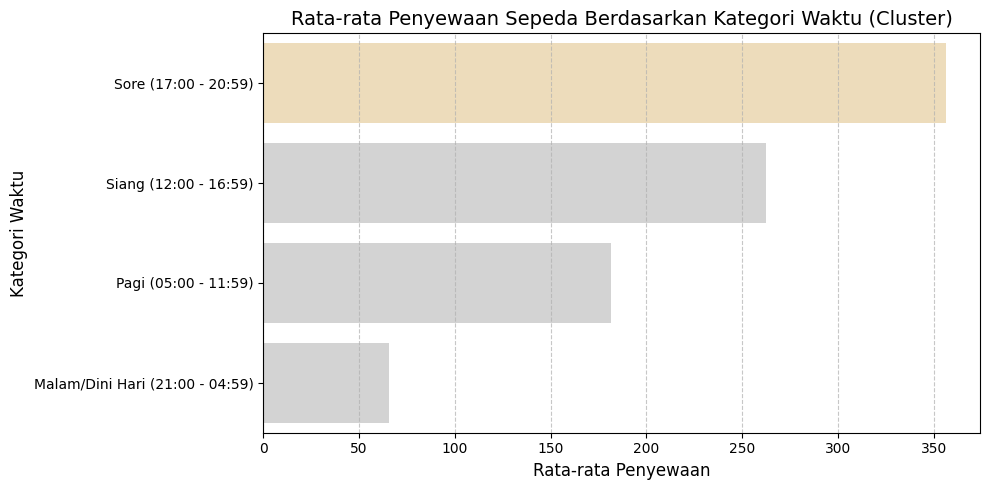

In [8]:
# --- CLUSTERING / BINNING ---
# Membuat fungsi untuk mengelompokkan jam ke dalam kategori waktu
def categorize_time(hour):
    if 5 <= hour < 12:
        return 'Pagi (05:00 - 11:59)'
    elif 12 <= hour < 17:
        return 'Siang (12:00 - 16:59)'
    elif 17 <= hour < 21:
        return 'Sore (17:00 - 20:59)'
    else:
        return 'Malam/Dini Hari (21:00 - 04:59)'

# Menerapkan fungsi binning ke dataset hour_df
hour_df['time_cluster'] = hour_df['hr'].apply(categorize_time)

# Agregasi data berdasarkan cluster waktu
cluster_summary = hour_df.groupby('time_cluster')['cnt'].mean().sort_values(ascending=False).reset_index()

print("=== Hasil Clustering Berdasarkan Kategori Waktu ===")
display(cluster_summary)

# Visualisasi Hasil Clustering
plt.figure(figsize=(10, 5))
# Menggunakan warna light grey dan cream
colors = ['#F5DEB3' if x == cluster_summary['cnt'].max() else '#D3D3D3' for x in cluster_summary['cnt']]
sns.barplot(x='cnt', y='time_cluster', data=cluster_summary, palette=colors)
plt.title('Rata-rata Penyewaan Sepeda Berdasarkan Kategori Waktu (Cluster)', fontsize=14)
plt.xlabel('Rata-rata Penyewaan', fontsize=12)
plt.ylabel('Kategori Waktu', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Conclusion & Recommendation

- **Conclusion Pertanyaan 1:** Pengguna *registered* (berlangganan) mendominasi secara absolut jumlah penyewaan sepeda pada rentang jam sibuk di hari kerja dibandingkan pengguna *casual*. Lonjakan tertinggi terjadi pada rentang waktu sore hari, yakni pukul 17:00 dan 18:00. Fakta ini menegaskan bahwa layanan sepeda ini lebih banyak dimanfaatkan sebagai moda transportasi komuter utama oleh pekerja kantoran untuk rutinitas harian mereka.
- **Conclusion Pertanyaan 2:** Terdapat korelasi linier yang positif antara suhu udara yang dirasakan (*atemp*) dengan total penyewaan sepeda harian (*cnt*). Musim Gugur (*Fall*) mencatatkan total penyewaan rata-rata tertinggi karena didukung oleh rentang suhu yang paling optimal bagi pengendara, berkebalikan dengan musim dingin (*Winter*) yang mengalami penurunan permintaan akibat cuaca yang kurang mendukung.
- **Conclusion Analisis Lanjutan (Clustering):** Berdasarkan pengelompokan waktu operasional, kategori "Sore (17:00 - 20:59)" menyumbang rata-rata penyewaan tertinggi. Hal ini semakin memperkuat temuan bahwa pergerakan armada paling intensif terjadi setelah jam pulang kerja atau sekolah.

**Rekomendasi Action Item:**
- **Optimalisasi Distribusi Armada (Fokus Operasional):** Tim logistik harus melakukan *re-balancing* atau alokasi ulang sepeda secara proaktif ke stasiun-stasiun yang berdekatan dengan area pusat perkantoran dan stasiun transit. Tindakan ini harus selesai minimal 30 menit sebelum jam 08:00 pagi dan 17:00 sore setiap hari kerja untuk memastikan pelanggan *registered* tidak kehabisan unit.
- **Penerapan *Dynamic Pricing* & Promo Musiman (Fokus Marketing):** Mengingat sensitivitas pengguna terhadap suhu, tim marketing disarankan meluncurkan kampanye diskon khusus atau tarif dinamis (misalnya *"Winter Ride Promo"*) pada hari-hari dengan suhu udara rendah atau saat musim dingin. Strategi ini ditujukan untuk menstimulasi pengguna *casual* agar tetap tertarik melakukan penyewaan meskipun cuaca sedang tidak ideal.